# 非線形

## 多項式特徴量

In [1]:
import seaborn as sns
df = sns.load_dataset('mpg')
df.dropna(inplace=True)

In [2]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


<Axes: xlabel='horsepower', ylabel='mpg'>

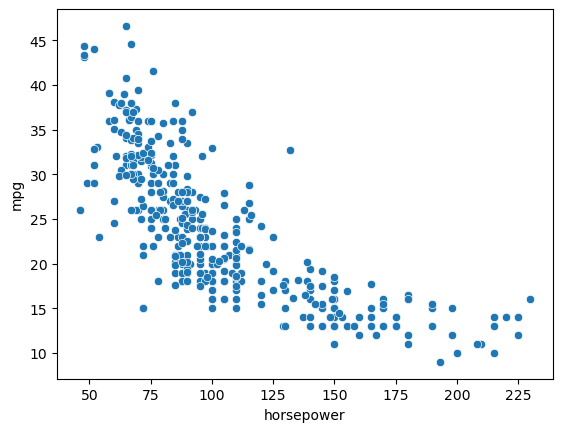

In [3]:
X = df['horsepower'].values.reshape(-1, 1)
y = df['mpg']
sns.scatterplot(x=df['horsepower'], y=df['mpg'])

In [4]:
# 多項式特徴量
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(2, include_bias=False)

In [5]:
poly

,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [6]:
# poly.fit(X)
# poly.transform(X)
X_poly = poly.fit_transform(X)

In [7]:
# 線形回帰
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_poly, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


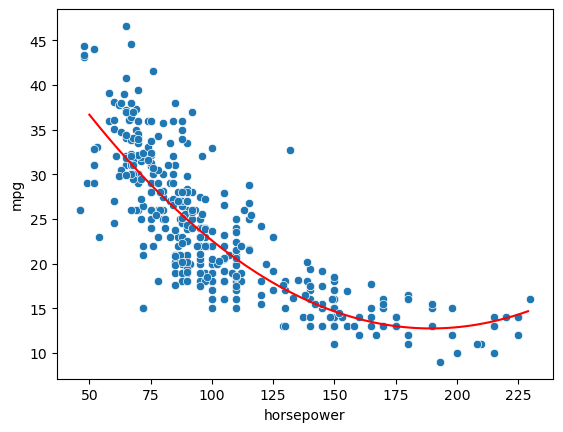

In [8]:
# 描画
import numpy as np
import matplotlib.pyplot as plt
x_axis = np.arange(50, 230).reshape(-1, 1)
x_axis_ = poly.fit_transform(x_axis)
pred = model.predict(x_axis_)
sns.scatterplot(x=df['horsepower'], y=df['mpg'])
plt.plot(x_axis, pred, 'r')

# 線形回帰　VS 非線形

In [9]:
from sklearn.model_selection import cross_val_score, RepeatedKFold
from sklearn.pipeline import Pipeline

In [10]:
X = df['horsepower'].values.reshape(-1, 1)
y = df['mpg']
degrees = [1, 2, 3]
model = LinearRegression()
k = 5
n_repeats = 3
cv = RepeatedKFold(n_splits=k, n_repeats=n_repeats, random_state=0)
results = {}
for d in degrees:
    poly = PolynomialFeatures(d)
    X_poly = poly.fit_transform(X)
    scores = cross_val_score(model, X_poly, y, scoring='neg_mean_squared_error', cv=cv)
    results[f"degree{d}"] = {'scores_mean':-np.mean(scores), 'scores_std':np.std(scores)}

In [11]:
scores

array([-15.91065108, -22.1624462 , -21.16531541, -24.32069337,
       -12.95586189, -18.54514929, -17.03665635, -31.06863501,
       -14.68685054, -16.08622087, -17.7286585 , -20.30767593,
       -17.0969599 , -17.68090829, -24.75449275])

In [12]:
results

{'degree1': {'scores_mean': np.float64(24.235391801372007),
  'scores_std': np.float64(3.3466777741729725)},
 'degree2': {'scores_mean': np.float64(19.294969517171623),
  'scores_std': np.float64(4.413627004206255)},
 'degree3': {'scores_mean': np.float64(19.43381169297633),
  'scores_std': np.float64(4.5082238230144975)}}

In [13]:
import pandas as pd
pd.DataFrame(results)

,degree1,degree2,degree3
scores_mean,24.235392,19.294970,19.433812
scores_std,3.346678,4.413627,4.508224


In [14]:
X = df['horsepower'].values.reshape(-1, 1)
y = df['mpg']
degrees = [1, 2, 3]
k = 5
n_repeats = 3
cv = RepeatedKFold(n_splits=k, n_repeats=n_repeats, random_state=0)
results = {}
for d in degrees:
    pipeline = Pipeline(steps=[('poly', PolynomialFeatures(d)), ('model', LinearRegression())])
    scores = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=cv)
    results[f"degree{d}"] = {'scores_mean':-np.mean(scores), 'scores_std':np.std(scores)}

In [15]:
pd.DataFrame(results)

,degree1,degree2,degree3
scores_mean,24.235392,24.235392,24.235392
scores_std,3.346678,3.346678,3.346678


## kNN回帰

<Axes: ylabel='mpg'>

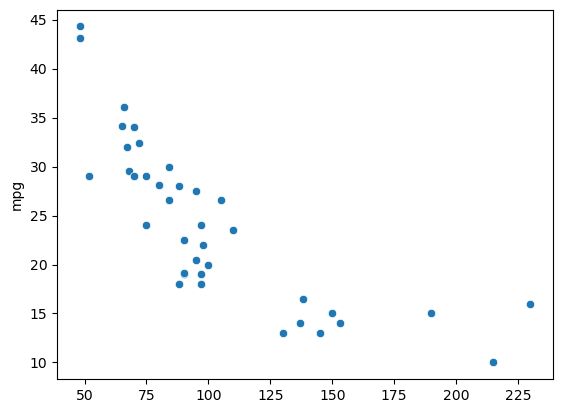

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.9, random_state=0)
sns.scatterplot(x=X_train[:, 0], y=y_train)

In [20]:
X_train.shape

(39, 1)

In [23]:
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=10)
model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Text(0.5, 0, 'horsepower')

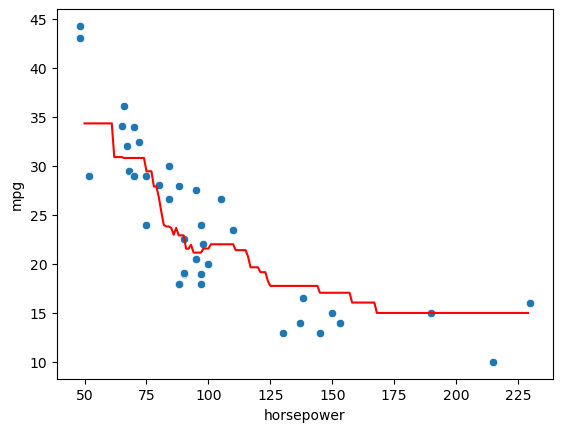

In [26]:
x_axis = np.arange(50, 230).reshape(-1, 1)
y_pred = model.predict(x_axis)
sns.scatterplot(x=X_train[:, 0], y=y_train)
plt.plot(x_axis, y_pred, 'r')
plt.xlabel('horsepower')

## kNN回帰の比較

In [27]:
k_list = np.arange(1, 31)

In [28]:
k_list

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])

In [31]:
k = 5
n_repeats = 3
cv = RepeatedKFold(n_splits=k, n_repeats=n_repeats, random_state=0)
score_list = []
for k in k_list:
    model = KNeighborsRegressor(n_neighbors=k)
    scores = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=cv)
    score_list.append(-np.mean(scores))

In [32]:
scores

array([-15.24126765, -19.4580398 , -20.72581439, -22.37003761,
       -14.60978575, -16.87551744, -17.22327046, -29.31718647,
       -14.54487179, -16.70306453, -16.38574107, -21.21526878,
       -18.01725954, -16.68031068, -21.42294459])

In [33]:
score_list

[np.float64(30.266313534566695),
 np.float64(24.460363599480687),
 np.float64(22.508170002524434),
 np.float64(21.174589148544843),
 np.float64(20.17598572325003),
 np.float64(19.597965676728336),
 np.float64(19.37652084644309),
 np.float64(18.995532125662667),
 np.float64(19.00758305183903),
 np.float64(18.606762631180352),
 np.float64(18.572447860923123),
 np.float64(18.69645316726171),
 np.float64(18.43521544402385),
 np.float64(18.57622420110531),
 np.float64(18.617488292641884),
 np.float64(18.78621223704763),
 np.float64(18.74668463107029),
 np.float64(18.84212491167824),
 np.float64(18.813188173546322),
 np.float64(18.855048798820732),
 np.float64(18.793536751842357),
 np.float64(18.80607495576282),
 np.float64(18.831141974092894),
 np.float64(18.835495582242416),
 np.float64(18.778628594871794),
 np.float64(18.804826413495707),
 np.float64(18.758288495932188),
 np.float64(18.730841401490807),
 np.float64(18.74182028396204),
 np.float64(18.71935870400423)]

Text(0, 0.5, '5fold cv error(MSE)')

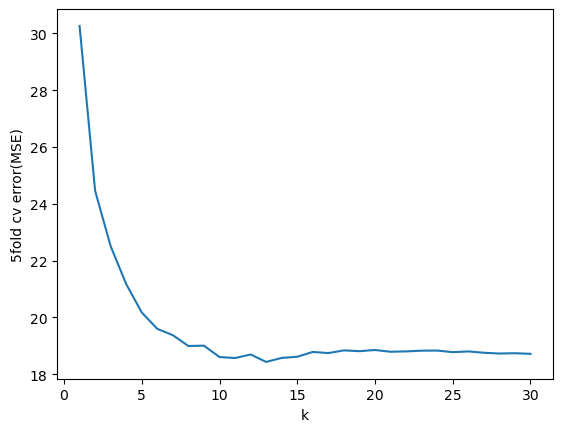

In [34]:
plt.plot(k_list, score_list)
plt.xlabel('k')
plt.ylabel('5fold cv error(MSE)')

In [36]:
print(f"Best performance: k={k_list[np.argmin(score_list)]}, cv error={np.min(score_list)}")

Best performance: k=13, cv error=18.43521544402385
